# Simplest Neural ODE

##### ***By Nino (Antonino) Sabella & Gabriel Brown***

Understanding the model:
- It is a model where the ***change of a hidden state (model memory) over time is defined by a neural network*** instead of a fixed function.
- Traditional neural networks have data pass through discrete layers, but here in Neural ODE, the ***layers are continuous***.
- **Inputs**: Data (usually an input feature vector) - usually written as h(t0). This is the data at time 0.
- **What the model does**: Model learns a function F (of a small neural network) that tells me the rate of change (how h(t) moves as time increases)
- **Output**: After solving the ODE from t0 to t1, the final hidden state of t1 is h(t1). This value can be used for a task such as classification, regression or forecasting.

Learning process of the model:
- **Forward pass**: When given the input, the model passes the input through all layers (continuous evolution) and produces an output.
- **Backpropagation**: This is how the neural networks learn. It involves calculating how much each parameter (weights in NN) contributed to the output error and then updating them to reduce that error next time. **In ODE's the model recreates the steps (each layer output) in reverse to figure out how earlier states must have looked.** Traditional NN's save every layer's output to later calculate how each one affected the final result. **The ODE approach is more memory efficient than traditional NN's**. This *works because ODE's describe reversible and continuous dynamics* (each step forward can be taken backward if function F is smooth and has no missing data points).



## Script 1: Pure Jax Implementation of dy/dt = F0(y,t)
- Small Neural Network
- Integration using Euler Method
- Training on Synethetic Data (y(t) = sin(t)) with gradient descent
- Visualization of learned curve annealing toward the sine wave

#### Breaking it down before getting into code:

**NUMBER 1**

dy/dt = F0(y,t) is an Ordinary Differential Equation (ODE) that says "*the rate of change of y, with respect to time t, is given by function F0(y,t)*".

**NUMBER 2**

Neural network implementation means we need to **LEARN** the formula given a set of inputs and outputs. (we don't automatically know the formula).
- Inputs: y & t
- Outputs: predicted rate of change dy/dt

**NUMBER 3**

Euler method is the easiest way to simulate an ODE. It takes tiny steps forward in time using Yt+1 = Yt + (step_size * F0(Yt, t)). 

We repeatedly apply this update to move from starting point y(0) to later times.


**NUMBER 4**

For the synthetic data, we will pretend the true curve is y(t) = sin(t). 

The ODE neural network will seek to **learn the rate of change** of this synthetic curve given the data we feed it. Perfect performance from the ODE NN would be the function **F0(Yt, t) = cos(t)**.
- y(t) = sin(t), the output matches sine
- dy/dt = cos(t), the rate of change of y(t) matches cosine
- dy/dt = F0(y,t) = cos(t)

**So outside of the ODE neural network, if the ODE did its part perfectly, the Euler update function would result in the sine curve.**

**NUMBER 5**

After training we are to plot the predicted curve (Euler update outputs) and the real sine curve together.

At first the Euler curve will be wrong, but as it learns (over epochs), its **output will gradually "anneal" (move closer and closer) to the true sine wave**.
- Before training, the NN predictions are basically random
- During training, the NN adjusts weights to make the predicted rate of change F0(y,t) closer to cos(t)
- After training, the Euler-updated (prediction) curve will be near true sine wive.

pip install jax jaxlib

In [31]:
import jax
import jax.numpy as jnp

In [32]:
from jax import grad, jit
import matplotlib.pyplot as plt

**Jax** is the main library. It contains functions like jax.grad and jax.jit.
- **jax.grad** computes the gradient (derivative) of a function automatically.
- **jax.jit** makes a function to run faster by transforming it into optimized machine code.

Jax.numpy (**JNP**) works like numpy but on accelerators. It supports automatic differentiation.

In [33]:
time = jnp.linspace(0, 2*jnp.pi, 300)
y_true = jnp.sin(time)      

#### Synthetic Data

jnp.linspace(start, stop, num) contains 300 evenly spaced numbers between 0 and 2*pi
- This are **data points in time**

jnp.sin(t_data) calculates the sine of each data point in time
- This are the **y values for every point in time**

In [34]:
def init_nn_params(key, input_dim=2, hidden_dim=16, output_dim=1):
    key1, key2 = jax.random.split(key)
    params = {
        'W1': jax.random.normal(key1, (input_dim, hidden_dim)) * 0.1,
        'b1': jnp.zeros(hidden_dim),
        'W2': jax.random.normal(key2, (hidden_dim, output_dim)) * 0.1,
        'b2': jnp.zeros(output_dim)
    }
    return params

def nn(params, y, t):
    x = jnp.stack([y, t])  # input: [y, t]
    h = jnp.tanh(jnp.dot(x, params['W1']) + params['b1'])
    out = jnp.dot(h, params['W2']) + params['b2']
    return out[0]  # scalar derivative

#### ODE Neural Network

**init_nn_params function is to initialize the NN's weights and biases.** It has inputs:
- key: random seed for reproducibility in JAX
- input_dim: the number of inputs taken by the network (2: y, t)
- hidden_dim=16: the hidden layer (model memory) has 16 neurons
- output_dim=1: the network outputs 1 value (predicted dy/dt)

Key was split into two new keys for Weight 1 and Weight 2 to keep the two random number vectors independent.

Params:
- Weight 1 has shape (2, 16) for the 2 inputs and 16 hidden neurons. Weight 1 (numerical vector) connects the input and hidden layer. (multiplied by 0.1 to start with small numbers)
- Biases for hidden layer are initialized to 0. Shape (16,) for hidden neurons.
- Weight 2 has shape (16,1) for the 16 hidden neurons and 1 output. It connects the hidden layer to the output.
- Bias for the output neuron is initialized to 0. Shape (1,) for output.

The init_nn_params function returns a dictionary of all weights and biases.

**nn function defines the nerual network function** It has inputs:
- params: the dictionary of weights and biases
- y: the current value of the curve
- t: current time

x = jnp.stack([y,t]) makes y and t into one singular input array of shape (2,) to be fed into the network.

h is the hidden layer output, shape (16,):
- jnp.dot(x,W1) computes the linear combination for the hidden layer neurons and + b1 adds the bias
- tanh activation function is applied to make the network nonlinear (able to learn non-linear relationships)

out is the network's predicted derivative (dy/dt), size (1,):
- jnp.dot(h,W2) + b2 gives the linear combination from the hidden layer + bias

The function finishes by extracting the single number from the output vector of shape (1,).

In [35]:
def euler_integration(params, y0, time, step_size=0.01):
    y_pred = [y0]
    y = y0
    for t in time[:-1]:
        dy = nn(params, y, t)
        y = y + step_size * dy
        y_pred.append(y)
    return jnp.array(y_pred)

#### Euler Update

**euler_integration function incorporates the ODE in the euler method update to get the predicted y value at the next moment in time.** It has inputs:
- params: the dictionary of weights for the neural network
- y0: the initial value of the curve Y(t0)
- time: the array of time points to integrate over
- step_size=0.01: the small increment used for each euler step (filling the gaps between discrete time values)

y_pred contains a list of predicted values of y at each time step, beginning with y0.

The function runs through every data point in the list of time points, and for each:
- gets the rate of change of y given t predicted by ODE
- adds the current y value to the product of the step size and the predicted dy to get the new predicted y at the moment in time
- appends the  new predicted y

The final output of the euler integration is the array of predicted y values (which hopefully closely resemble a sin(t) when plotted).

In [36]:
def loss(params, y0, time, y_true, step_size=0.01):
    y_pred = euler_integration(params, y0, time, step_size)
    return jnp.mean((y_pred - y_true)**2)

grad_loss = jit(grad(loss))

#### Loss Function

**loss function calculates how far the predicted curve is from the true curve**. inputs:
- params: NN weights & biases
- y0: initial value of the curve
- time: array of time points
- y_true: the true target values of y at each time point (sin(t))
- step_size=0.01: the small increments for the euler update (filling gaps in time to be continuous)

The loss function gets the y_pred array and finds the mean squared error.

**grad(loss)** automatically computes the gradient of the loss with respect to the network parameters. This is the information needed to update the network weights during training
- **jit** (just in time) is the JAX function for making the gradient function more efficient (faster) in computation

Epoch 0, Loss: 0.6918


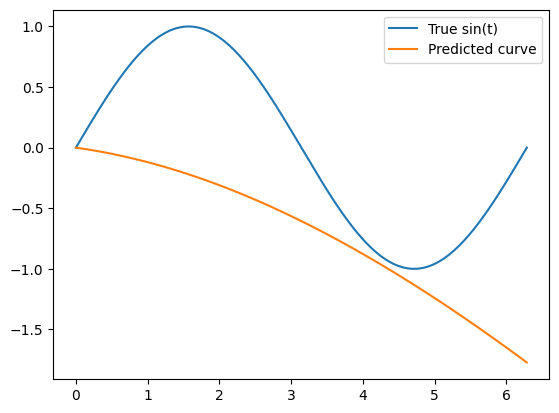

Epoch 200, Loss: 0.1116


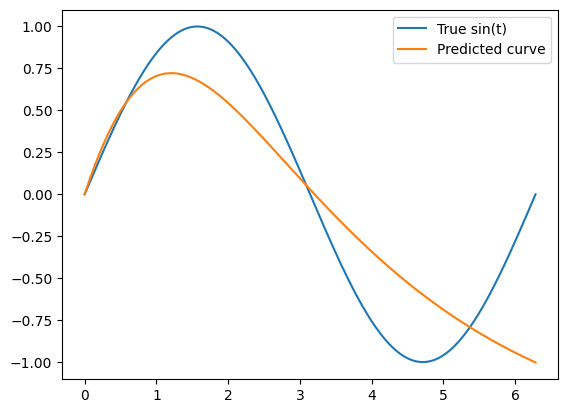

Epoch 400, Loss: 0.0588


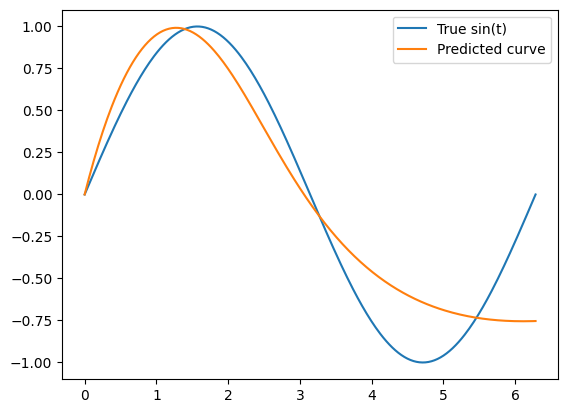

Epoch 600, Loss: 0.0433


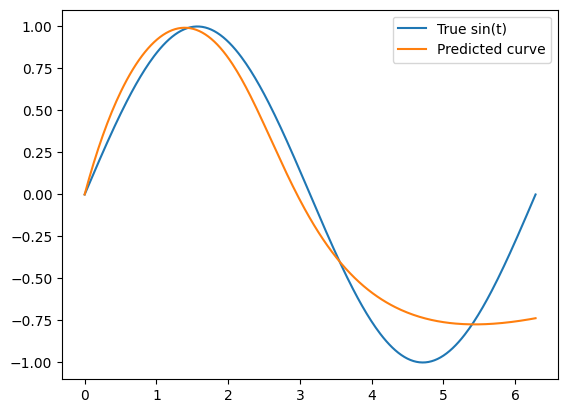

Epoch 800, Loss: 0.0460


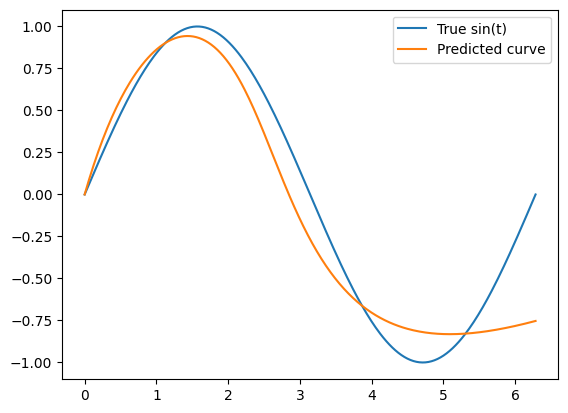

Epoch 1000, Loss: 0.0409


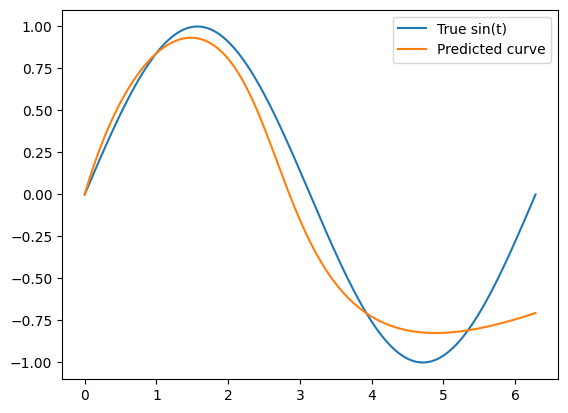

In [37]:
key = jax.random.PRNGKey(0)
params = init_nn_params(key)
y0 = 0.0
lr = 0.15
epochs = 1000

for epoch in range(epochs+1):
    grads = grad_loss(params, y0, time, y_true)
    params = {k: params[k] - lr * grads[k] for k in params}
    if epoch % 200 == 0:
        current_loss = loss(params, y0, time, y_true)
        print(f"Epoch {epoch}, Loss: {current_loss:.4f}")
        y_pred = euler_integration(params, y0, time, step_size=0.01)

        plt.plot(time, y_true, label='True sin(t)')
        plt.plot(time, y_pred, label='Predicted curve')
        plt.legend()
        plt.show()

#### Training Loop & Visualization

Here the neural network is trained to learn the derivative function F0(y,t)

key = jax.random.PRNGKey(0) creates the random seed for initializing weights reproducibly in JAX.
- params = init_nn_params(key) initializes the NN weights and biases

lr is learning rate (changed to opitmize result)
y0 is first y value of the curve for euler integration
1000 epochs were used in learning (trials)

In each epoch:
- gradients of the loss with respect to the network params are computed and gathered (assessing what can be done better within the model)
- params are updated to be equal to old param - (lr * gradient of the param)
- if the epoch is divisible by 200, then we print the MSE and show the visual comparison of the euler predictions and real values (sin(t))

## Script 2: Diffrax

Instead of using the Euler method (a simple, fixed-step integrator), we will now use **diffrax.diffqsolve**. This lets us use advanced ODE solvers like Tsit5.
- The solver will *automatically choose step sizes* to keep the error low, instead of manually using step_size in a loop.

In [38]:
pip install diffrax


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
import diffrax

In [40]:
def f(t, y, args):
    params = args
    return nn(params, y, t)

def diffrax_integration(params, y0, time):
    solver = diffrax.Tsit5()  
    saveat = diffrax.SaveAt(ts=time)  
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f),
        solver,
        t0=time[0],
        t1=time[-1],
        dt0=0.01,
        y0=y0,
        args=params,
        saveat=saveat
    )
    return sol.ys 

#### ODE Function and Diffrax Function

**f defines the ODE function for Diffrax**. Takes in t, y and params. Outputs predicted dy/dt at any point t, y.

**diffrax integration returns the predicted curve (replacing euler method).** inputs:
- params: NN weights & biases
- y0: initial value of y
- time: array of time points where we want predictions

solver = diffrax.Tsits5()
- select Tsits5 solver which is good for ODE, it will automatically adjust step sizes to be optimal

saveat tells solver to return predictions exactly at points in time from our array of time points.

diffrax.diffeqsolve gets the entire curve instead of just one data point (like euler that only gets next data point). it has inputs:
- diffrax.ODETerm(f): wraps the ODE function f for the solver
- solver: the integration method to use (Tsit5)
- t0: intial time
- t1: final time
- dt0: initial step size
- y0: starting value of curve
- args=params: passes NN params into f
- saveat=saveat: saves solution (pred_y vals) to the desired time points

The diffrax integatrion function returns the pred_y valyes for all the time points in time. shape is (len(time), ). this is the same shape as y_true.

Epoch 0, Loss: 6.6522


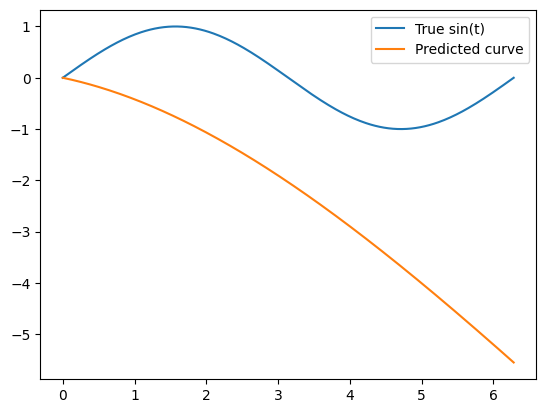

Epoch 200, Loss: 0.0489


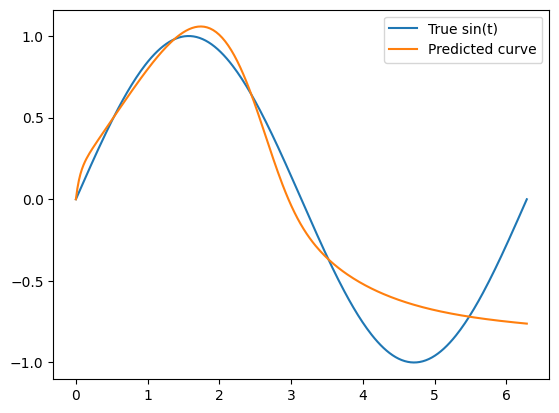

Epoch 400, Loss: 0.0478


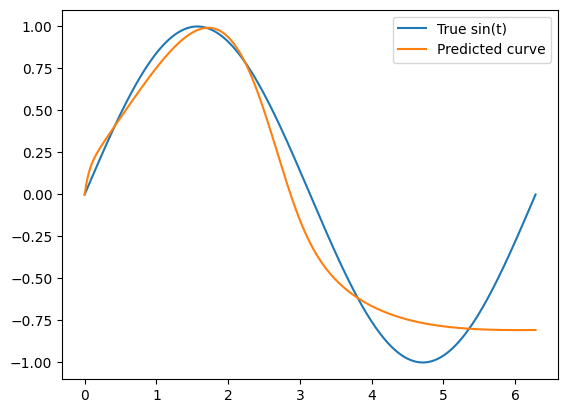

Epoch 600, Loss: 0.0439


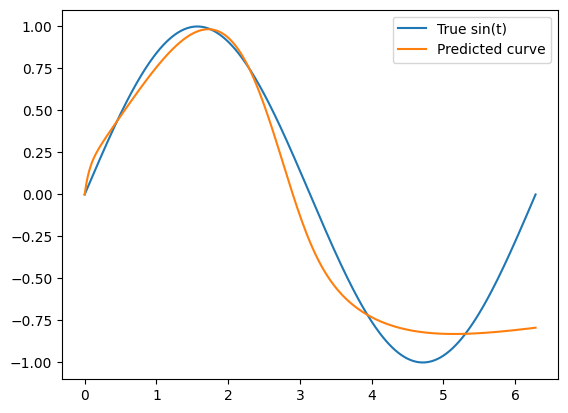

Epoch 800, Loss: 0.0426


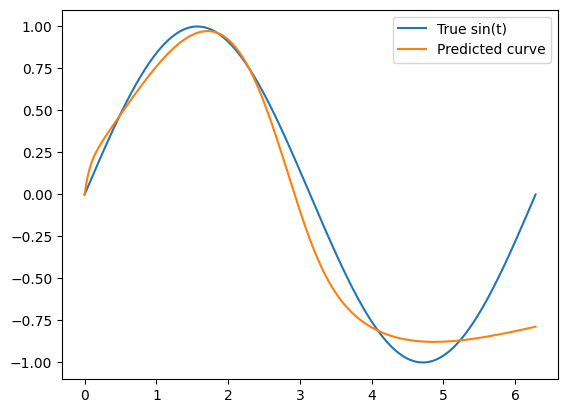

Epoch 1000, Loss: 0.0338


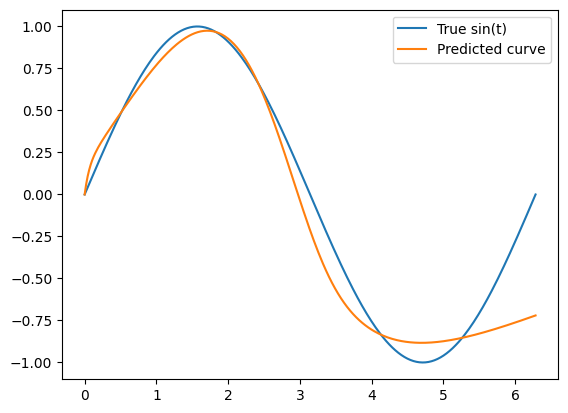

In [42]:
def loss(params, y0, time, y_true):
    y_pred = diffrax_integration(params, y0, time)
    return jnp.mean((y_pred - y_true)**2)

grad_loss = jit(grad(loss))

key = jax.random.PRNGKey(0)
params = init_nn_params(key)
y0 = 0.0
lr = 0.12
epochs = 1000

for epoch in range(epochs+1):
    grads = grad_loss(params, y0, time, y_true)
    params = {k: params[k] - lr * grads[k] for k in params}
    if epoch % 200 == 0:
        current_loss = loss(params, y0, time, y_true)
        print(f"Epoch {epoch}, Loss: {current_loss:.4f}")
        y_pred = diffrax_integration(params, y0, time)
        plt.plot(time, y_true, label='True sin(t)')
        plt.plot(time, y_pred, label='Predicted curve')
        plt.legend()
        plt.show()